In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate Realistic HR Data
np.random.seed(42)
num_employees = 1000

ages = np.random.randint(22, 60, num_employees)
roles = np.random.choice(['Sales Executive', 'Research Scientist', 'Laboratory Technician', 'Manufacturing Director', 'Manager'], num_employees)
years_at_company = np.random.randint(1, 15, num_employees)

# Logical calculation for Monthly Income based on experience
monthly_income = (years_at_company * 1200) + np.random.randint(3000, 8000, num_employees)

# Probability of Attrition (Higher attrition for lower salary and fewer years)
attrition_prob = 1 / (1 + np.exp((monthly_income - 9000) / 2000 + (years_at_company - 3) / 2))
attrition = np.where(np.random.rand(num_employees) < attrition_prob, 'Yes', 'No')

hr_df = pd.DataFrame({
    'Age': ages,
    'JobRole': roles,
    'MonthlyIncome': monthly_income,
    'YearsAtCompany': years_at_company,
    'Attrition': attrition
})

print("--- HR Dataset Snapshot ---")
print(hr_df.head())
print("\nTotal Attrition Count:")
print(hr_df['Attrition'].value_counts())

--- HR Dataset Snapshot ---
   Age                JobRole  MonthlyIncome  YearsAtCompany Attrition
0   50                Manager           9767               4        No
1   36        Sales Executive          16688               8        No
2   29                Manager          16778               8        No
3   42                Manager          20346              12        No
4   40  Laboratory Technician           5649               1       Yes

Total Attrition Count:
Attrition
No     825
Yes    175
Name: count, dtype: int64


--- Average Monthly Income by Attrition Status ---
Attrition
No     15801.67
Yes     8065.22
Name: MonthlyIncome, dtype: float64


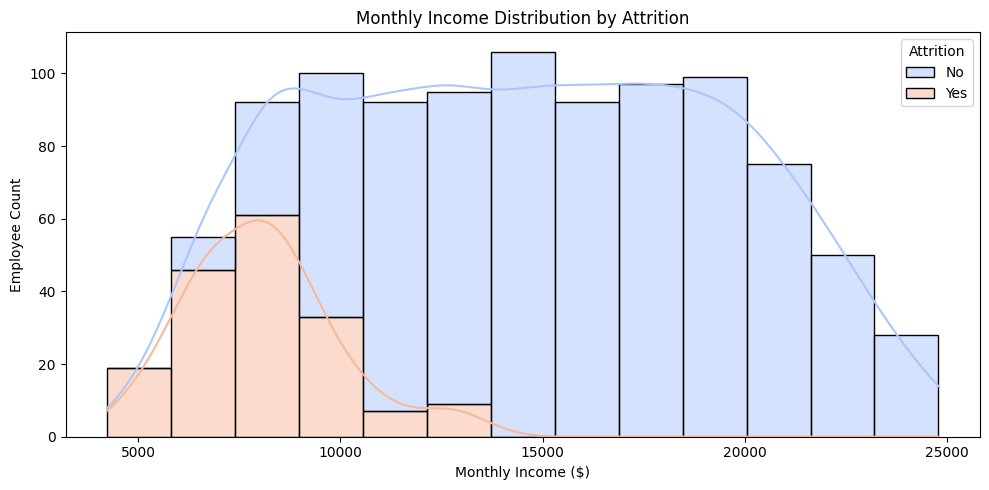

In [2]:
# Descriptive Statistics
print("--- Average Monthly Income by Attrition Status ---")
print(hr_df.groupby('Attrition')['MonthlyIncome'].mean().round(2))

# Histogram Plot
plt.figure(figsize=(10, 5))
sns.histplot(data=hr_df, x='MonthlyIncome', hue='Attrition', multiple='stack', kde=True, palette='coolwarm')
plt.title('Monthly Income Distribution by Attrition')
plt.xlabel('Monthly Income ($)')
plt.ylabel('Employee Count')
plt.tight_layout()
plt.show()

--- Attrition Percentage by Job Role ---
Attrition                  No    Yes
JobRole                             
Laboratory Technician   83.96  16.04
Manager                 84.06  15.94
Manufacturing Director  81.96  18.04
Research Scientist      81.31  18.69
Sales Executive         81.31  18.69


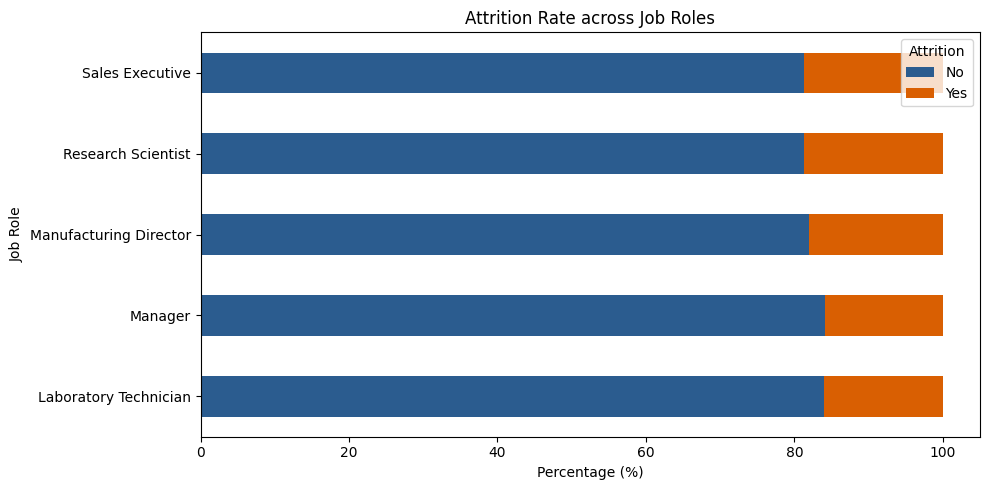

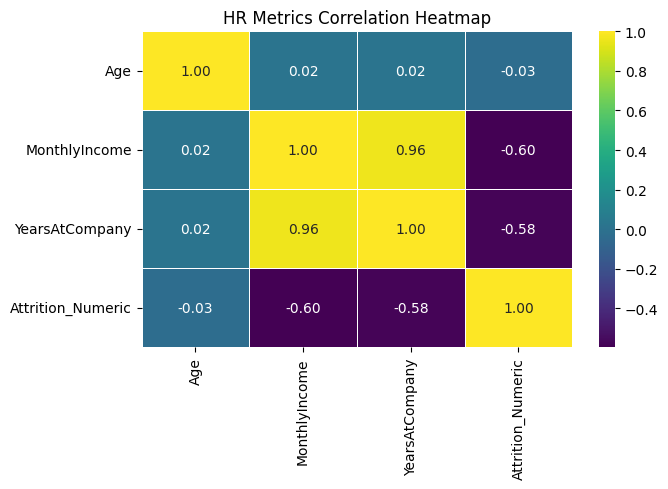

In [3]:
# 1. Crosstab: Job Role vs Attrition
job_attrition_cross = pd.crosstab(hr_df['JobRole'], hr_df['Attrition'], normalize='index') * 100
print("--- Attrition Percentage by Job Role ---")
print(job_attrition_cross.round(2))

# Plot Crosstab Bar Chart
job_attrition_cross.plot(kind='barh', stacked=True, figsize=(10, 5), color=['#2b5c8f', '#d95f02'])
plt.title('Attrition Rate across Job Roles')
plt.xlabel('Percentage (%)')
plt.ylabel('Job Role')
plt.legend(title='Attrition')
plt.tight_layout()
plt.show()

# 2. Correlation Heatmap (Converting Attrition to 1/0)
hr_df['Attrition_Numeric'] = hr_df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
corr_hr = hr_df[['Age', 'MonthlyIncome', 'YearsAtCompany', 'Attrition_Numeric']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_hr, annot=True, cmap='viridis', fmt='.2f', linewidths=0.5)
plt.title('HR Metrics Correlation Heatmap')
plt.tight_layout()
plt.show()